<a href="https://colab.research.google.com/github/suhaani1/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/Milestone3/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
# df=pd.read_csv('/content/clean - Copy.csv')
# Upload dataset manually in Colab
from google.colab import files
uploaded = files.upload()

# Example: change filename if needed
df = pd.read_csv(list(uploaded.keys())[0])

df.head()


Saving clean - Copy.csv to clean - Copy.csv


,date,participant_id,resting_heart_rate,daily_steps,hours_sleep
0,2016-04-12 00:00:00+00:00,5528405368,60.812500,0.141667,0.75
1,2016-04-12 00:01:00+00:00,5528405368,61.694927,0.141667,0.75
2,2016-04-12 00:02:00+00:00,5528405368,62.183333,0.141667,0.75
3,2016-04-12 00:03:00+00:00,5528405368,61.358334,0.141667,0.75
4,2016-04-12 00:04:00+00:00,5528405368,61.400000,0.141667,0.75


In [3]:
df

,date,participant_id,resting_heart_rate,daily_steps,hours_sleep
0,2016-04-12 00:00:00+00:00,5528405368,60.812500,0.141667,0.75
1,2016-04-12 00:01:00+00:00,5528405368,61.694927,0.141667,0.75
2,2016-04-12 00:02:00+00:00,5528405368,62.183333,0.141667,0.75
3,2016-04-12 00:03:00+00:00,5528405368,61.358334,0.141667,0.75
4,2016-04-12 00:04:00+00:00,5528405368,61.400000,0.141667,0.75
...,...,...,...,...,...
44176,2016-05-12 16:16:00+00:00,4558609924,75.222220,0.000000,0.00
44177,2016-05-12 16:17:00+00:00,4558609924,74.250000,0.000000,0.00
44178,2016-05-12 16:18:00+00:00,4558609924,73.714290,0.000000,0.00
44179,2016-05-12 16:19:00+00:00,4558609924,75.500000,0.000000,0.00


In [4]:
df.columns


Index(['date', 'participant_id', 'resting_heart_rate', 'daily_steps',
       'hours_sleep'],
      dtype='object')

In [5]:
df = df.rename(columns={'participant_id': 'id'})


In [6]:
value_cols = ['resting_heart_rate', 'daily_steps', 'hours_sleep']

ts_df = df.melt(
    id_vars=['id', 'date'],
    value_vars=value_cols,
    var_name='kind',
    value_name='value'
)


In [7]:
from tsfresh import extract_features

tsfresh_df = extract_features(
    ts_df, # Use the melted DataFrame
    column_id='id',
    column_sort='date',
    column_kind='kind',
    column_value='value',
    default_fc_parameters=None
)

Feature Extraction: 100%|██████████| 1734/1734 [04:04<00:00,  7.10it/s]


In [8]:
tsfresh_df = tsfresh_df.fillna(0)

In [9]:
# from prophet import Prophet

# def run_prophet(df, value_col):
#     temp = df[['date', value_col]].rename(
#         columns={'date': 'ds', value_col: 'y'}
#     )

#     model = Prophet(
#         daily_seasonality=True,
#         weekly_seasonality=True
#     )

#     model.fit(temp)
#     forecast = model.predict(temp)

#     return forecast
def run_prophet(df, value_col, periods=14):

    temp = df[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'}
    )

    temp['ds'] = pd.to_datetime(temp['ds'], errors='coerce')
    temp = temp.dropna().sort_values('ds')

    if temp.shape[0] < 2:
        print(f"⚠️ Skipping Prophet for {value_col}: insufficient data")
        return None

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True
    )

    model.fit(temp)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return forecast


In [10]:
user_df = df[df['id'] == 1]

print("daily_steps valid:", user_df['daily_steps'].notna().sum())
print("resting_hr valid:", user_df['resting_heart_rate'].notna().sum())

user_df[['date', 'daily_steps', 'resting_heart_rate']].head(10)


daily_steps valid: 0
resting_hr valid: 0


,date,daily_steps,resting_heart_rate


In [11]:
prophet_steps = run_prophet(df[df['id'] == 1], 'daily_steps')
prophet_hr = run_prophet(df[df['id'] == 1], 'resting_heart_rate')


⚠️ Skipping Prophet for daily_steps: insufficient data
⚠️ Skipping Prophet for resting_heart_rate: insufficient data


In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = tsfresh_df.values

# Replace infinite values with 0.0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_scaled = StandardScaler().fit_transform(X)


In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
tsfresh_df['cluster'] = kmeans.fit_predict(X_scaled)


In [14]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=10)
tsfresh_df['dbscan_cluster'] = db.fit_predict(X_scaled)


In [15]:
from prophet import Prophet

def prophet_model(df, col):
    temp = df[['timestamp', col]].rename(
        columns={'timestamp': 'ds', col: 'y'}
    )

    model = Prophet(daily_seasonality=True)
    model.fit(temp)
    return model.predict(temp)


In [16]:
user_id = 1
user_df = df[df['id'] == user_id].copy()
user_df = user_df.sort_values('date')


In [17]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'}
    )
    # Remove timezone information as Prophet does not support it
    temp['ds'] = temp['ds'].dt.tz_localize(None)

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast

In [18]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'}
    )

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast


In [19]:
from prophet import Prophet
import pandas as pd

df_prophet = df.rename(columns={
    "date": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=10, freq="T")
forecast = model.predict(future)

forecast = forecast.merge(
    df_prophet[['ds', 'y']],
    on='ds',
    how='left'
)

forecast['residual'] = forecast['y'] - forecast['yhat']

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


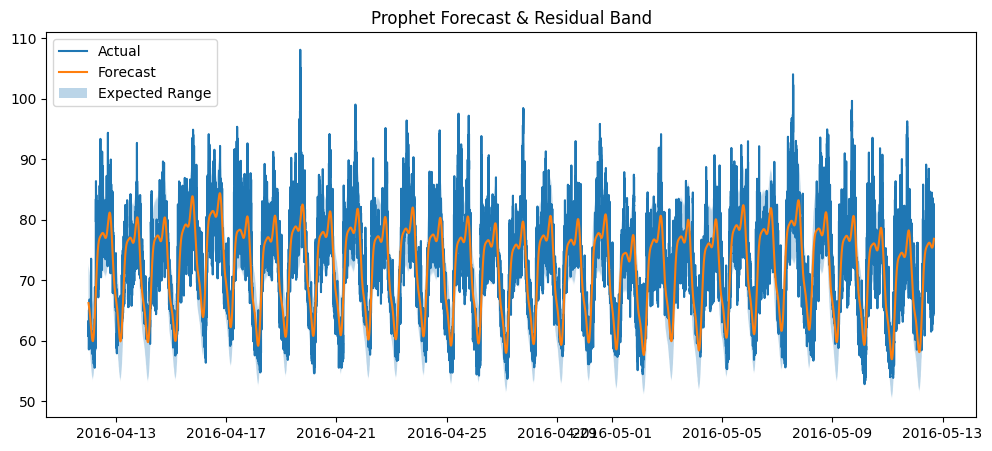

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast['ds'], forecast['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.3,
    label='Expected Range'
)
plt.legend()
plt.title("Prophet Forecast & Residual Band")
plt.show()

In [21]:
residual_std = forecast['residual'].std()

forecast['upper_threshold'] = forecast['yhat'] + 3 * residual_std
forecast['lower_threshold'] = forecast['yhat'] - 3 * residual_std


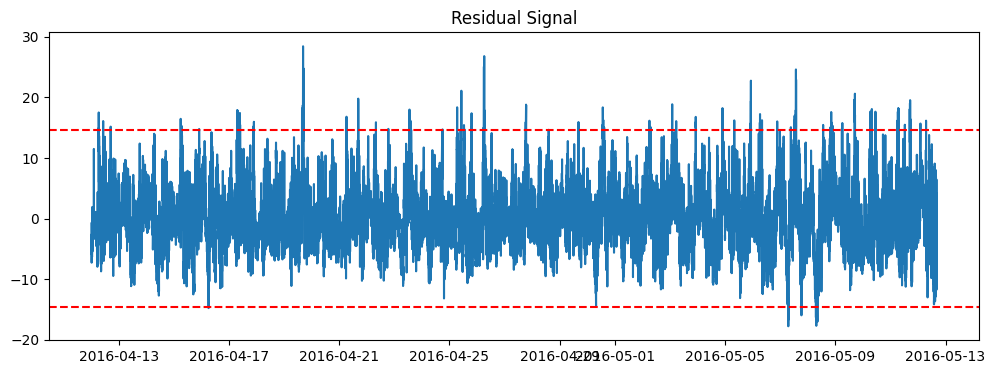

In [22]:
plt.figure(figsize=(12,4))
plt.plot(forecast['ds'], forecast['residual'])
plt.axhline(3*residual_std, color='red', linestyle='--')
plt.axhline(-3*residual_std, color='red', linestyle='--')
plt.title("Residual Signal")
plt.show()


In [23]:
from prophet import Prophet
import pandas as pd

df_prophet = df.rename(columns={
    "date": "ds",
    "daily_steps": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=10, freq="T")
forecast = model.predict(future)

forecast = forecast.merge(
    df_prophet[['ds', 'y']],
    on='ds',
    how='left'
)

forecast['residual'] = forecast['y'] - forecast['yhat']

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


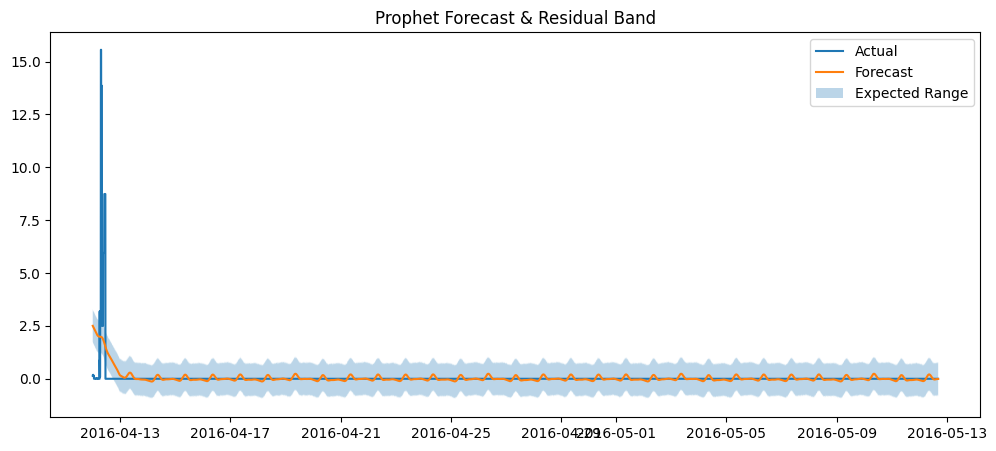

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast['ds'], forecast['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.3,
    label='Expected Range'
)
plt.legend()
plt.title("Prophet Forecast & Residual Band")
plt.show()

In [25]:
residual_std = forecast['residual'].std()

forecast['upper_threshold'] = forecast['yhat'] + 3 * residual_std
forecast['lower_threshold'] = forecast['yhat'] - 3 * residual_std


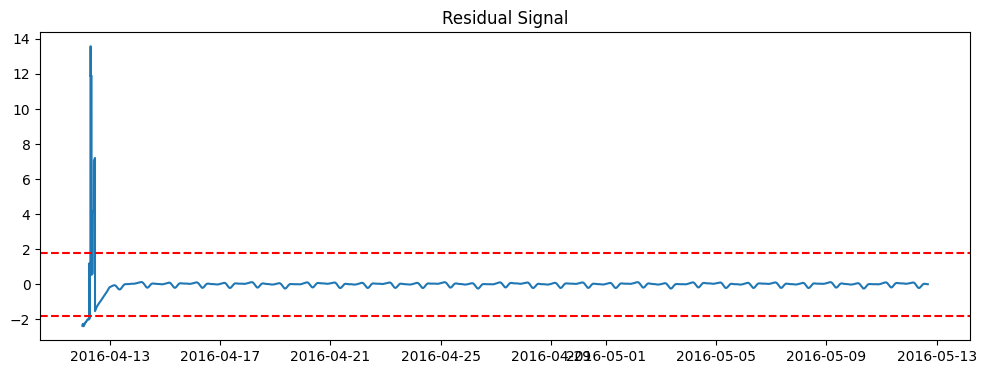

In [26]:
plt.figure(figsize=(12,4))
plt.plot(forecast['ds'], forecast['residual'])
plt.axhline(3*residual_std, color='red', linestyle='--')
plt.axhline(-3*residual_std, color='red', linestyle='--')
plt.title("Residual Signal")
plt.show()


In [27]:
from prophet import Prophet
import pandas as pd

df_prophet = df.rename(columns={
    "date": "ds",
    "hours_sleep": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=10, freq="T")
forecast = model.predict(future)

forecast = forecast.merge(
    df_prophet[['ds', 'y']],
    on='ds',
    how='left'
)

forecast['residual'] = forecast['y'] - forecast['yhat']

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


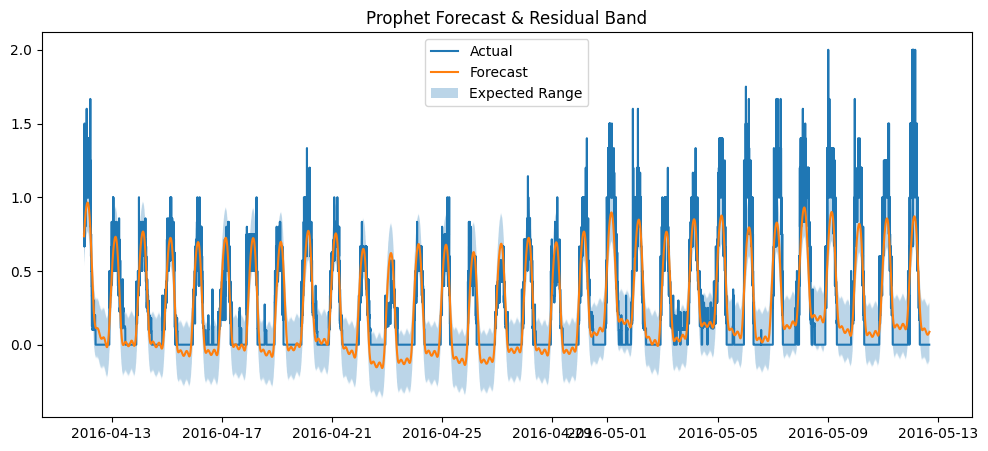

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(forecast['ds'], forecast['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.3,
    label='Expected Range'
)
plt.legend()
plt.title("Prophet Forecast & Residual Band")
plt.show()

In [29]:
residual_std = forecast['residual'].std()

forecast['upper_threshold'] = forecast['yhat'] + 3 * residual_std
forecast['lower_threshold'] = forecast['yhat'] - 3 * residual_std


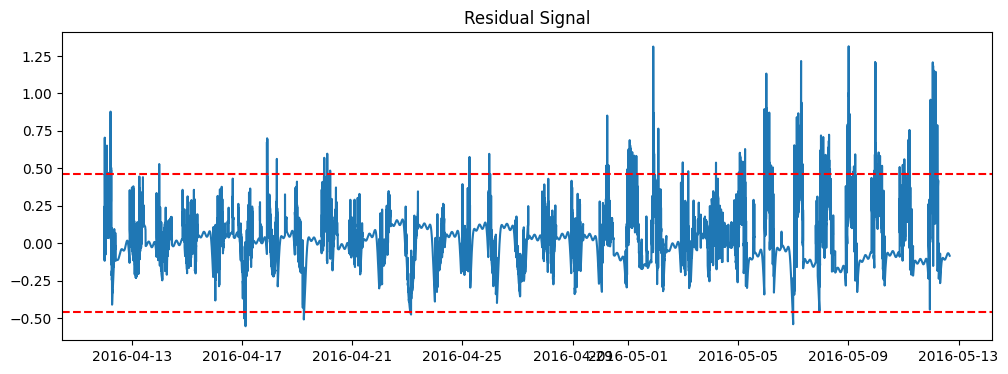

In [30]:
plt.figure(figsize=(12,4))
plt.plot(forecast['ds'], forecast['residual'])
plt.axhline(3*residual_std, color='red', linestyle='--')
plt.axhline(-3*residual_std, color='red', linestyle='--')
plt.title("Residual Signal")
plt.show()


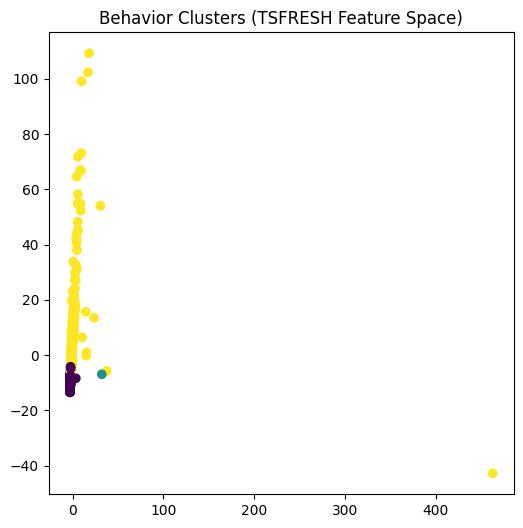

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=tsfresh_df['cluster'])
plt.title("Behavior Clusters (TSFRESH Feature Space)")
plt.show()
